# 01 — Initial analysis: JKP themes as domain experts

**Which Expert, When?** First look at the US JKP panel (1990 →).

1. Build the universe (JKP large + small size groups: NYSE 20th–80th size percentile) and check coverage
2. Rebuild the 13 JKP theme long-short factors from the stock-level characteristics
3. Show that theme performance is unstable over time (the motivation for gating)
4. Build naive, *unfitted* theme experts (average signed rank of each theme's characteristics)
5. Check whether expert skill depends on **stock-level** and **market-level** states — i.e. whether a gate has anything to learn

All figures are saved to `outputs/figures/` for slides. Expert scores are saved to `data/interim/` for the modeling step.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scripts" / "get_jkp_us.py").exists()), None)
assert ROOT is not None, "Run this notebook from inside the repo (couldn't find scripts/get_jkp_us.py)"
RAW, INTERIM, FIG = ROOT / "data" / "raw", ROOT / "data" / "interim", ROOT / "outputs" / "figures"
RAW.mkdir(parents=True, exist_ok=True)
INTERIM.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

START_YEAR, END_YEAR = 1990, 2025   # years of JKP data to load (missing years are downloaded)
SIZE_GROUPS = ["large", "small"]   # JKP size groups analysed: large + small = NYSE 20th-80th size percentile
UNIVERSE = "_".join(SIZE_GROUPS)   # "large_small": used in figure titles and saved file names
ROLL = 36              # months, for rolling statistics

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

def save(fig, name):
    fig.savefig(FIG / f"{name}.png")

def ann_stats(r: pd.Series) -> pd.Series:
    r = r.dropna()
    return pd.Series({
        "Ann. ret %": r.mean() * 1200,
        "Ann. vol %": r.std() * np.sqrt(12) * 100,
        "Sharpe": r.mean() / r.std() * np.sqrt(12),
        "t-stat": r.mean() / r.std() * np.sqrt(len(r)),
    })

## 1. Load data and theme map

In [2]:
import sys
sys.path.insert(0, str(ROOT / "scripts"))
import get_jkp_us

tm_path = RAW / "theme_map.csv"
if not tm_path.exists():   # normally saved by the download script; rebuild from JKP's GitHub otherwise
    get_jkp_us.load_metadata()[1].to_csv(tm_path, index=False)
theme_map = pd.read_csv(tm_path)

# Download any missing years from WRDS (needs a WRDS account)
missing = [y for y in range(START_YEAR, END_YEAR + 1) if not (get_jkp_us.OUT / f"{y}.parquet").exists()]
if missing:
    print(f"Downloading {len(missing)} missing year(s) from WRDS: {missing}")
    get_jkp_us.download(get_jkp_us.load_metadata()[0], years=missing)   # prompts for WRDS login

files = sorted(p for p in (RAW / "jkp_us").glob("*.parquet") if START_YEAR <= int(p.stem) <= END_YEAR)
raw = pd.concat((pd.read_parquet(p) for p in files), ignore_index=True)
raw["eom"] = pd.to_datetime(raw["eom"])
assert "mega" in set(raw["size_grp"]), "No mega stocks loaded: they are needed for the weight cap in §3"

chars = [c for c in theme_map["characteristic"] if c in raw.columns]
raw["me"] = pd.to_numeric(raw["me"], errors="coerce").astype("float64")
raw["ret_exc_lead1m"] = pd.to_numeric(raw["ret_exc_lead1m"], errors="coerce").astype("float64")

theme_map = theme_map[theme_map["characteristic"].isin(chars)].reset_index(drop=True)
theme_of = theme_map.set_index("characteristic")["cluster"]
THEMES = sorted(theme_of.unique())

print(f"Years loaded: {files[0].stem}-{files[-1].stem}")
print(f"{len(raw):,} stock-months | {raw['id'].nunique():,} stocks | {len(chars)} characteristics | {len(THEMES)} themes")
theme_of.value_counts().rename("# characteristics").to_frame().T

Years loaded: 1990-2025
1,007,693 stock-months | 12,854 stocks | 153 characteristics | 13 themes


cluster,Investment,Value,Low Risk,Quality,Seasonality,Profit Growth,Low Leverage,Profitability,Momentum,Debt Issuance,Accruals,Short-Term Reversal,Size
# characteristics,22,18,18,17,12,12,11,11,8,7,6,6,5


## 2. Universe

Universe 'large_small': 832,982 stock-months, median 1807 stocks/month
Smallest stock in universe: $0.10bn (Jan 1990) -> $0.77bn (Dec 2025)


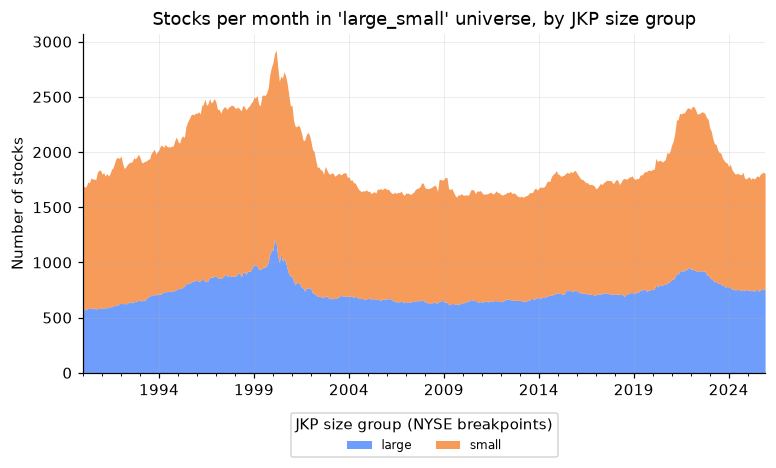

In [3]:
def select_universe(df, groups=SIZE_GROUPS):
    # keeps only SIZE_GROUPS: mega is loaded in raw but excluded here (raw's mega rows only set the weight cap in §3)
    return df[df["me"].notna() & df["size_grp"].isin(groups)]

panel = select_universe(raw).sort_values(["eom", "id"]).reset_index(drop=True)
g = panel["eom"]  # month grouper used throughout

# What the universe contains: JKP size groups (NYSE breakpoints) and the smallest stock that gets in
SIZE_ORDER = ["mega", "large", "small", "micro", "nano"]
composition = panel.groupby(["eom", "size_grp"])["id"].count().unstack(fill_value=0)
composition = composition[[s for s in SIZE_ORDER if s in composition.columns]]
cutoff_bn = panel.groupby("eom")["me"].min() / 1000   # me is in $ millions

fig, ax = plt.subplots(figsize=(8, 4))
composition.plot.area(ax=ax, stacked=True, linewidth=0, alpha=0.85)
ax.set(title=f"Stocks per month in '{UNIVERSE}' universe, by JKP size group", xlabel="", ylabel="Number of stocks")
ax.legend(title="JKP size group (NYSE breakpoints)", loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=8)
save(fig, "01_universe")

print(f"Universe '{UNIVERSE}': {len(panel):,} stock-months, median {composition.sum(axis=1).median():.0f} stocks/month")
print(f"Smallest stock in universe: ${cutoff_bn.iloc[0]:.2f}bn ({cutoff_bn.index[0]:%b %Y}) -> ${cutoff_bn.iloc[-1]:.2f}bn ({cutoff_bn.index[-1]:%b %Y})")


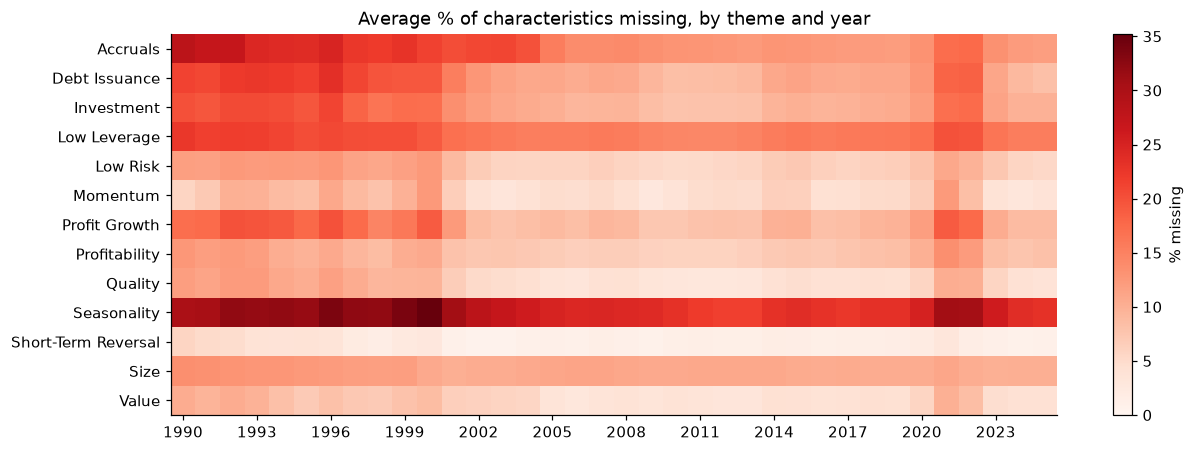

In [4]:
miss = panel[chars].isna().groupby(panel["eom"].dt.year).mean().T          # chars x years
miss_theme = miss.groupby(theme_of).mean().loc[THEMES] * 100

fig, ax = plt.subplots(figsize=(13, 4.5))
im = ax.imshow(miss_theme.values, aspect="auto", cmap="Reds", vmin=0)
ax.set_yticks(range(len(THEMES)), THEMES)
step = max(1, len(miss_theme.columns) // 12)
ax.set_xticks(range(0, len(miss_theme.columns), step), miss_theme.columns[::step])
ax.grid(False)
ax.set_title("Average % of characteristics missing, by theme and year")
fig.colorbar(im, ax=ax, label="% missing")
save(fig, "02_missingness")

## 3. Signals: signed cross-sectional ranks

Each month, every characteristic is ranked across stocks, centred to [-0.5, 0.5], and multiplied by JKP's `direction`
so that **higher = higher expected return** for every characteristic. Missing values are set to 0 (the cross-sectional median).

In [5]:
direction = theme_map.set_index("characteristic")["direction"].reindex(chars).fillna(1).astype("float32")
ranks = panel.groupby(g)[chars].rank(pct=True).astype("float32")
ranks = ((ranks - 0.5) * direction).fillna(0.0)

ret = panel["ret_exc_lead1m"]
valid = ret.notna()
# JKP capped value weights: cap at the NYSE 80th percentile, where JKP's mega group starts
# (the only use of mega stocks in this notebook). With no mega stocks in the universe the cap
# never binds, so these are plain value weights.
nyse_p80 = raw.loc[raw["size_grp"] == "mega"].groupby("eom")["me"].min()   # smallest mega stock each month
me_cap = panel["me"].clip(upper=panel["eom"].map(nyse_p80))
w = me_cap.where(valid, 0.0)
wr = w * ret.fillna(0.0)

def long_short(score, lo, hi):
    """Capped value-weighted long (score > hi) minus short (score < lo); indexed by formation month."""
    L, S = score > hi, score < lo
    rl = (wr * L).groupby(g).sum() / (w * L).groupby(g).sum()
    rs = (wr * S).groupby(g).sum() / (w * S).groupby(g).sum()
    return rl - rs

def to_holding(df):
    """Re-index from formation month t to the month the return is earned (t+1)."""
    out = df.copy()
    out.index = out.index + pd.offsets.MonthEnd(1)
    return out

## 4. Rebuilding the 13 JKP theme factors

Tercile long-short per characteristic (top third minus bottom third, capped value weights), then an equal-weighted average
within each theme — the JKP construction. JKP cap weights at the NYSE 80th percentile, where their mega group starts; our universe
has no mega stocks, so the cap never binds and these are plain value weights. JKP build theirs from all stocks, so these will differ
somewhat from the US theme factors published on jkpfactors.com.

In [6]:
char_ls = pd.DataFrame({c: long_short(ranks[c], -1/6, 1/6) for c in chars})
theme_ls = to_holding(char_ls.T.groupby(theme_of).mean().T[THEMES].dropna(how="all"))

theme_stats = theme_ls.apply(ann_stats).T.sort_values("Sharpe", ascending=False)
theme_stats.round(2)

,Ann. ret %,Ann. vol %,Sharpe,t-stat
cluster,,,,
Debt Issuance,2.25,2.94,0.77,4.59
Seasonality,1.37,2.12,0.64,3.85
Quality,3.60,5.96,0.60,3.62
Profitability,3.93,9.53,0.41,2.47
Investment,2.97,8.41,0.35,2.12
Momentum,4.42,12.75,0.35,2.08
Accruals,1.25,3.80,0.33,1.97
Profit Growth,1.05,4.07,0.26,1.54
Value,3.67,14.39,0.25,1.53


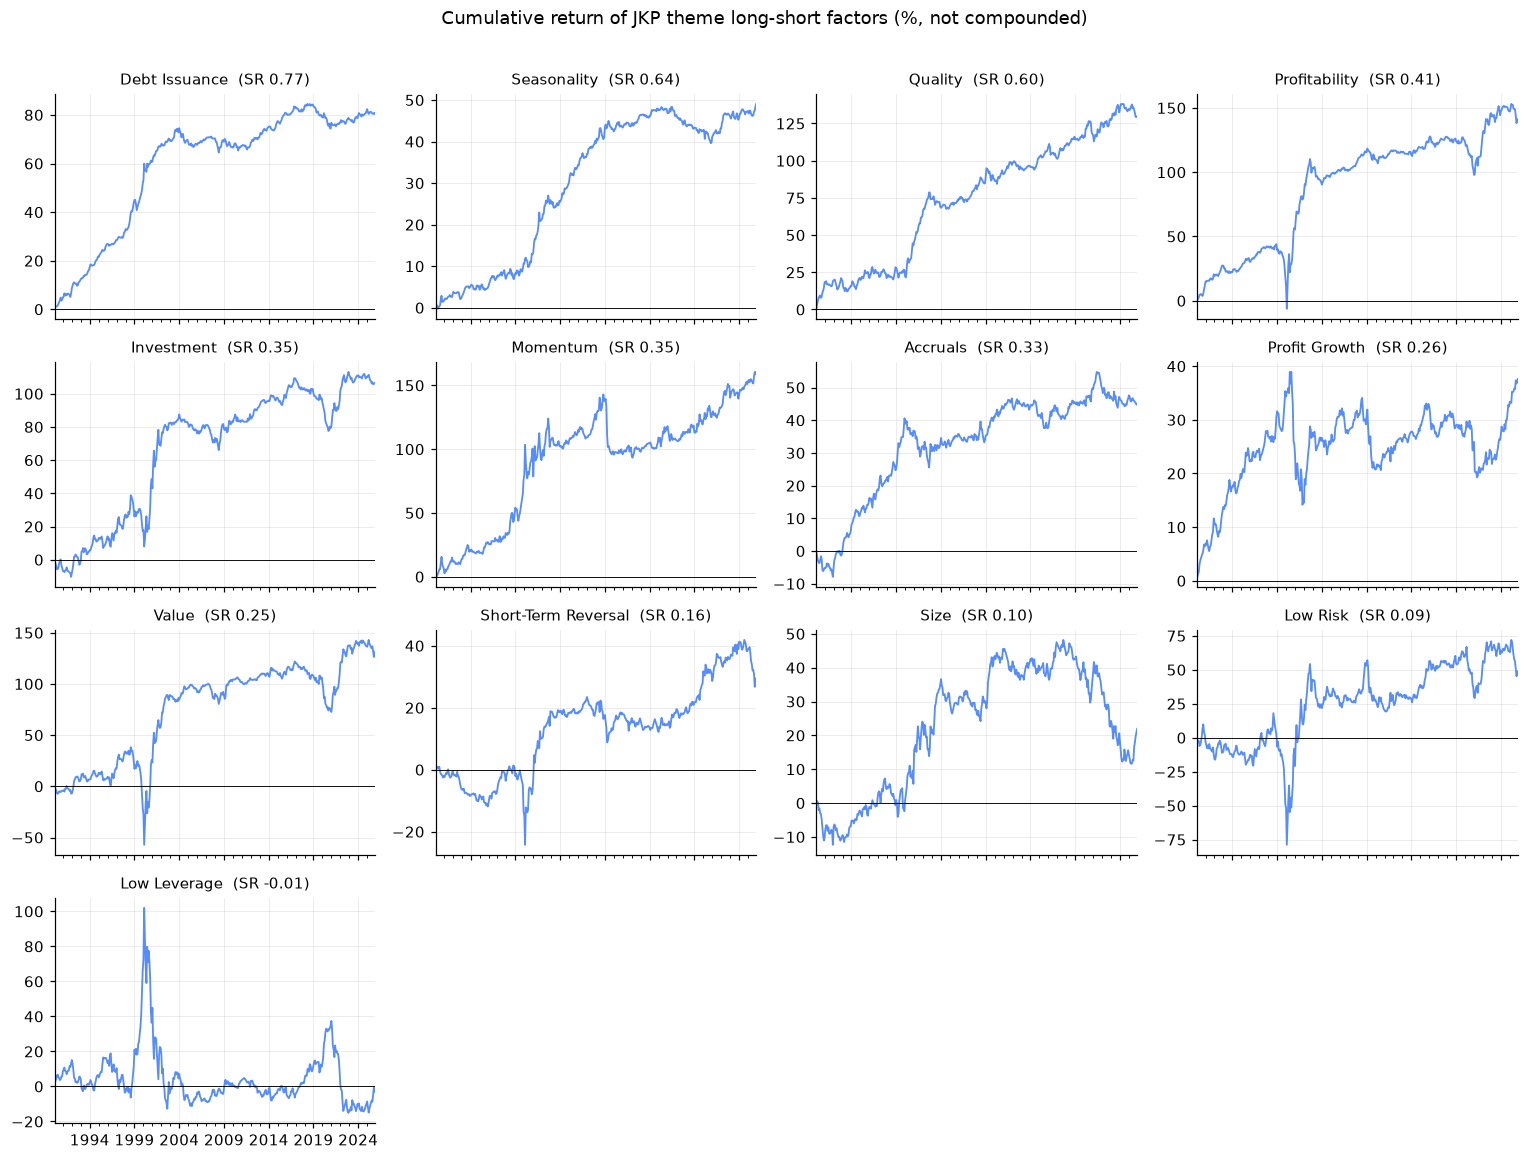

In [7]:
ncol = 4
nrow = int(np.ceil(len(THEMES) / ncol))
order = theme_stats.index
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 2.6 * nrow), sharex=True)
for ax, t in zip(axes.flat, order):
    (theme_ls[t].fillna(0).cumsum() * 100).plot(ax=ax, color="C0", lw=1.2)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{t}  (SR {theme_stats.loc[t, 'Sharpe']:.2f})", fontsize=10)
    ax.set_xlabel("")
for ax in axes.flat[len(THEMES):]:
    ax.set_visible(False)
fig.suptitle("Cumulative return of JKP theme long-short factors (%, not compounded)", y=1.01)
fig.tight_layout()
save(fig, "03_theme_cumulative")

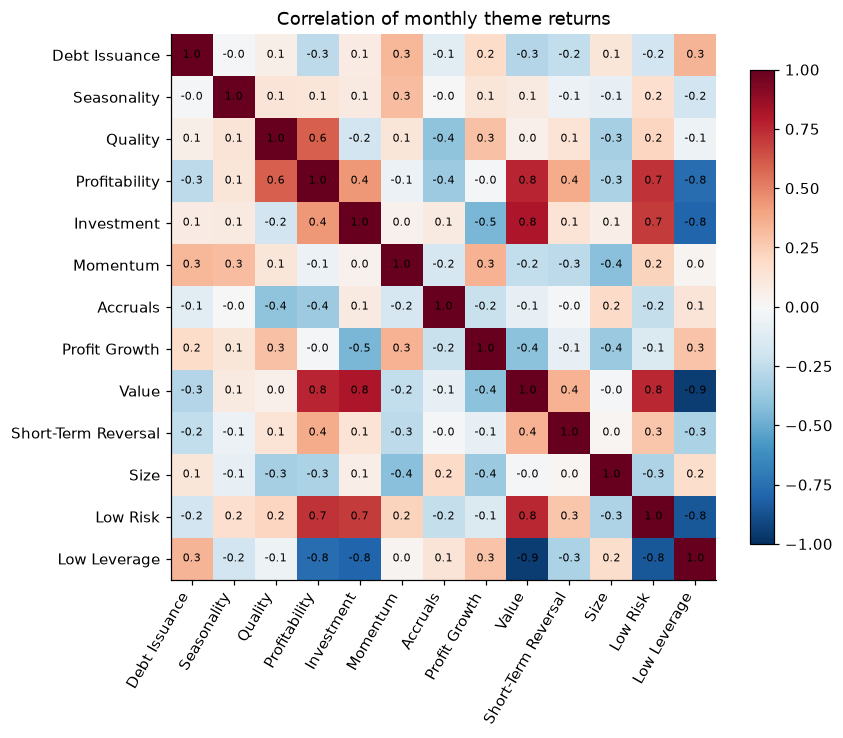

In [8]:
corr = theme_ls.corr().loc[order, order]
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(order)), order, rotation=60, ha="right")
ax.set_yticks(range(len(order)), order)
for i in range(len(order)):
    for j in range(len(order)):
        ax.text(j, i, f"{corr.values[i, j]:.1f}", ha="center", va="center", fontsize=7)
ax.grid(False)
ax.set_title("Correlation of monthly theme returns")
fig.colorbar(im, ax=ax, shrink=0.8)
save(fig, "04_theme_correlation")

### Are theme payoffs stable? Rolling Sharpe ratios

If every theme earned its premium steadily, there would be nothing for a gate to do. The heatmap shows rolling 36-month Sharpe ratios.

cluster,Debt Issuance,Seasonality,Quality,Profitability,Investment,Momentum,Accruals,Profit Growth,Value,Short-Term Reversal,Size,Low Risk,Low Leverage
% of windows with negative Sharpe,29.0,16.0,9.0,15.0,23.0,13.0,27.0,35.0,22.0,34.0,41.0,38.0,51.0


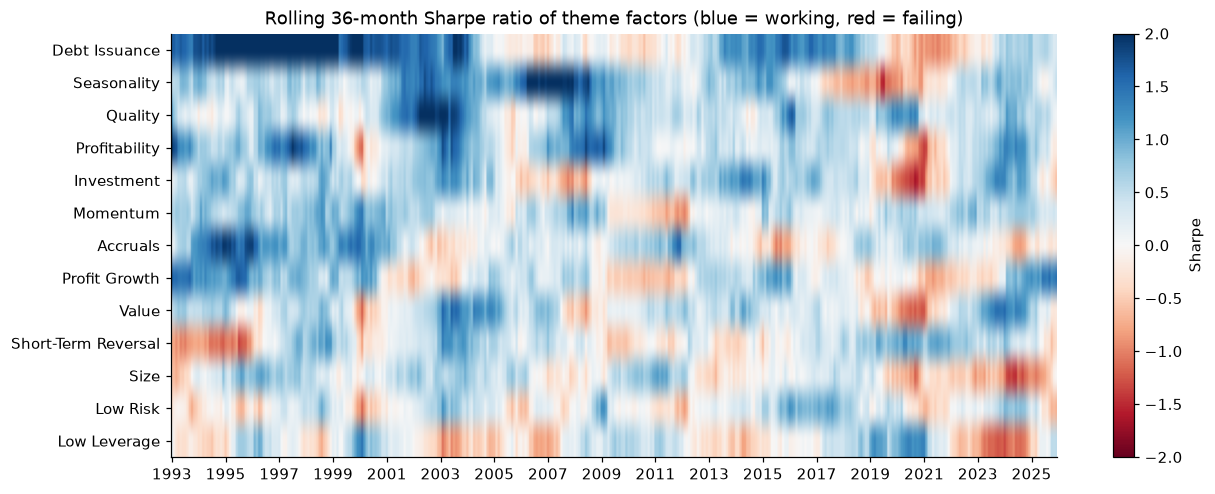

In [9]:
roll_sr = (theme_ls.rolling(ROLL).mean() / theme_ls.rolling(ROLL).std() * np.sqrt(12)).dropna(how="all")[order]

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(roll_sr.T.values, aspect="auto", cmap="RdBu", vmin=-2, vmax=2)
ax.set_yticks(range(len(order)), order)
yrs = roll_sr.index.year
tick_pos = [i for i in range(len(yrs)) if i == 0 or yrs[i] != yrs[i - 1]]
tick_pos = tick_pos[::max(1, len(tick_pos) // 12)]
ax.set_xticks(tick_pos, yrs[tick_pos])
ax.grid(False)
ax.set_title(f"Rolling {ROLL}-month Sharpe ratio of theme factors (blue = working, red = failing)")
fig.colorbar(im, ax=ax, label="Sharpe")
save(fig, "05_rolling_sharpe")

(roll_sr < 0).mean().mul(100).round(0).rename("% of windows with negative Sharpe").to_frame().T

## 5. Naive theme experts

Expert *k*'s score for stock *i* in month *t* = average signed rank of theme *k*'s characteristics, re-ranked within the month.
No fitting yet — this is the simplest possible expert and the baseline any fitted expert must beat. `EQWT` is the equal-weighted
average of the 13 expert scores (the "no gate" benchmark).

In [10]:
expert = pd.DataFrame({t: ranks[theme_of.index[theme_of == t]].mean(axis=1) for t in THEMES})
expert = expert.groupby(g).rank(pct=True) - 0.5
expert["EQWT"] = expert[THEMES].mean(axis=1)
expert["EQWT"] = expert.groupby(g)["EQWT"].rank(pct=True) - 0.5
EXPERTS = THEMES + ["EQWT"]

def monthly_ic(scores, mask=None):
    """Spearman rank IC per month between each score column and next-month return."""
    df = scores.assign(_ret=ret)
    keep = valid if mask is None else (valid & mask)
    df, grp = df[keep], g[keep]
    return df.groupby(grp).apply(lambda d: d.corr(method="spearman")["_ret"].drop("_ret"))

ic = monthly_ic(expert[EXPERTS])
ic_stats = pd.DataFrame({
    "Mean IC": ic.mean(),
    "IC IR (ann.)": ic.mean() / ic.std() * np.sqrt(12),
    "t-stat": ic.mean() / ic.std() * np.sqrt(ic.count()),
    "% months IC>0": (ic > 0).mean() * 100,
}).sort_values("Mean IC", ascending=False)
ic_stats.round(3)

,Mean IC,IC IR (ann.),t-stat,% months IC>0
_ret,,,,
EQWT,0.041,1.480,8.872,67.981
Profitability,0.037,1.224,7.335,63.109
Low Risk,0.036,0.645,3.868,54.756
Value,0.035,0.745,4.463,56.381
Quality,0.028,1.041,6.237,62.645
Momentum,0.020,0.525,3.147,57.309
Investment,0.015,0.494,2.960,53.828
Profit Growth,0.011,0.492,2.950,59.629
Short-Term Reversal,0.009,0.545,3.266,54.988


,Ann. ret %,Ann. vol %,Sharpe,t-stat
EQWT,14.11,17.28,0.82,4.89
Debt Issuance,6.46,8.28,0.78,4.68
Quality,9.42,15.00,0.63,3.76
Seasonality,4.74,9.76,0.49,2.91
Investment,8.17,17.99,0.45,2.72
Accruals,3.83,8.79,0.44,2.61
Profitability,8.84,21.30,0.41,2.49
Momentum,9.33,25.49,0.37,2.19
Profit Growth,4.04,13.23,0.31,1.83
Value,6.09,27.89,0.22,1.31


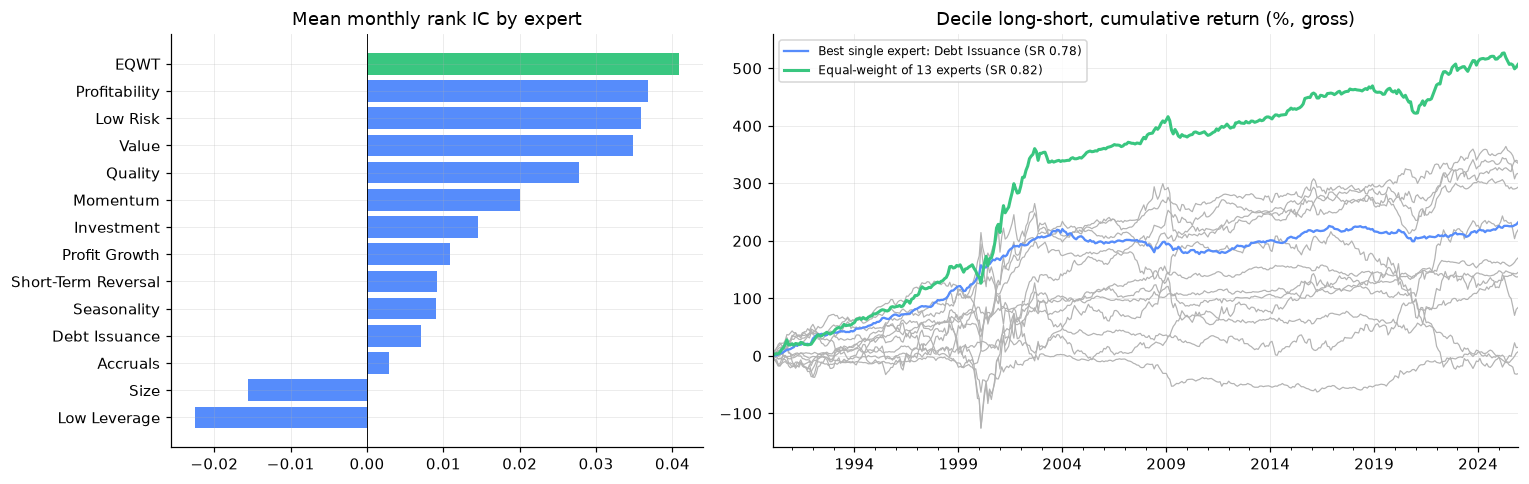

In [11]:
expert_ls = to_holding(pd.DataFrame({e: long_short(expert[e], -0.4, 0.4) for e in EXPERTS}).dropna(how="all"))
expert_stats = expert_ls.apply(ann_stats).T.sort_values("Sharpe", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 1.4]})
s = ic_stats["Mean IC"].sort_values()
axes[0].barh(s.index, s.values, color=["C3" if i == "EQWT" else "C0" for i in s.index])
axes[0].set_title("Mean monthly rank IC by expert")
axes[0].axvline(0, color="k", lw=0.6)

for e in THEMES:
    (expert_ls[e].fillna(0).cumsum() * 100).plot(ax=axes[1], color="0.7", lw=0.8, label="_nolegend_")
best = expert_stats.drop("EQWT")["Sharpe"].idxmax()
(expert_ls[best].fillna(0).cumsum() * 100).plot(ax=axes[1], color="C0", lw=1.5,
    label=f"Best single expert: {best} (SR {expert_stats.loc[best, 'Sharpe']:.2f})")
(expert_ls["EQWT"].fillna(0).cumsum() * 100).plot(ax=axes[1], color="C3", lw=2,
    label=f"Equal-weight of 13 experts (SR {expert_stats.loc['EQWT', 'Sharpe']:.2f})")
axes[1].set(title="Decile long-short, cumulative return (%, gross)", xlabel="")
axes[1].legend(loc="upper left", fontsize=8)
fig.tight_layout()
save(fig, "06_expert_baselines")
expert_stats.round(2)

## 6. Which expert, when? Conditional skill

The core question for the gate: **does an expert's skill depend on the state of the stock (or the market)?**
If expert ICs look the same in every bucket, gating can't help. If they differ — especially if the *ranking* of experts changes
across buckets — there's something to learn.

### 6a. Stock-level states (the Trexquant-style gate)
Within each month, stocks are split into terciles of each state variable and expert ICs are computed within each tercile.

,Size,Volatility,Liquidity,12m return
_ret,,,,
Accruals,-0.002000,0.007000,0.001000,0.002000
Debt Issuance,0.003000,0.007000,0.008000,-0.012000
Investment,-0.008000,0.016000,0.006000,-0.025000
Low Leverage,0.015000,-0.017000,0.004000,0.007000
Low Risk,-0.026000,0.024000,0.004000,-0.034000
Momentum,-0.013000,0.038000,0.002000,-0.012000
Profit Growth,-0.002000,0.004000,-0.005000,0.003000
Profitability,-0.013000,0.014000,-0.003000,-0.016000
Quality,-0.013000,0.029000,0.002000,-0.011000


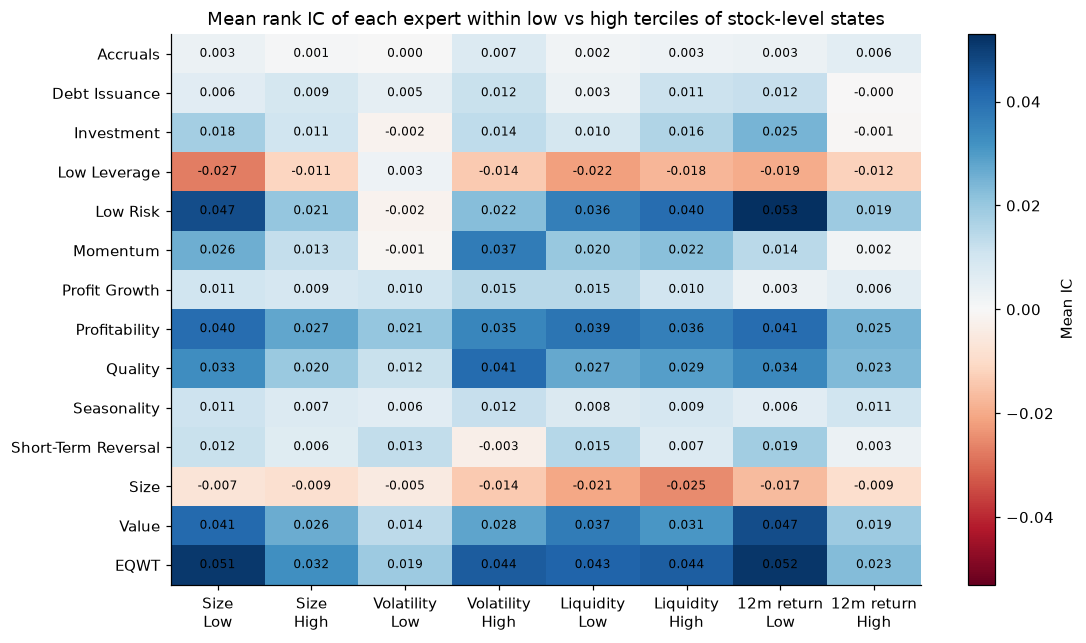

In [12]:
STATE_CANDIDATES = {
    "Size": "me",
    "Volatility": "rvol_21d",
    "Liquidity": "dolvol_126d",
    "12m return": "ret_12_1",
}
STATES = {k: v for k, v in STATE_CANDIDATES.items() if v in panel.columns}

rows = {}
for name, col in STATES.items():
    tercile = panel.groupby(g)[col].rank(pct=True)
    bucket = pd.cut(tercile, [0, 1/3, 2/3, 1], labels=["Low", "Mid", "High"])
    for b in ["Low", "High"]:
        rows[(name, b)] = monthly_ic(expert[EXPERTS], mask=(bucket == b)).mean()
cond_ic = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 6.5))
vmax = np.nanmax(np.abs(cond_ic.values))
im = ax.imshow(cond_ic.values, aspect="auto", cmap="RdBu", vmin=-vmax, vmax=vmax)
ax.set_yticks(range(len(cond_ic)), cond_ic.index)
ax.set_xticks(range(cond_ic.shape[1]), [f"{a}\n{b}" for a, b in cond_ic.columns])
for i in range(cond_ic.shape[0]):
    for j in range(cond_ic.shape[1]):
        ax.text(j, i, f"{cond_ic.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
ax.grid(False)
ax.set_title("Mean rank IC of each expert within low vs high terciles of stock-level states")
fig.colorbar(im, ax=ax, label="Mean IC")
save(fig, "07_conditional_ic_stock_states")

spread = pd.DataFrame({n: cond_ic[(n, "High")] - cond_ic[(n, "Low")] for n in STATES})
spread.round(3).style.background_gradient(cmap="RdBu", axis=None) if len(spread) else spread

Note: Size, Low Risk and Momentum experts contain the same variables used as states here, so their rows partly mechanically
reflect the conditioning. The cleaner evidence is for experts *unrelated* to the state (e.g. Value or Accruals across volatility terciles).

### 6b. Market-level states (the macro gate), built only from the panel itself

- **Market trend**: trailing 12-month value-weighted universe return (known at *t*), up vs down
- **Market volatility**: cross-sectional median of `rvol_21d`, above vs below its expanding median (no look-ahead)

Note the number of months in each state — this is the small-*N* problem with macro gating.

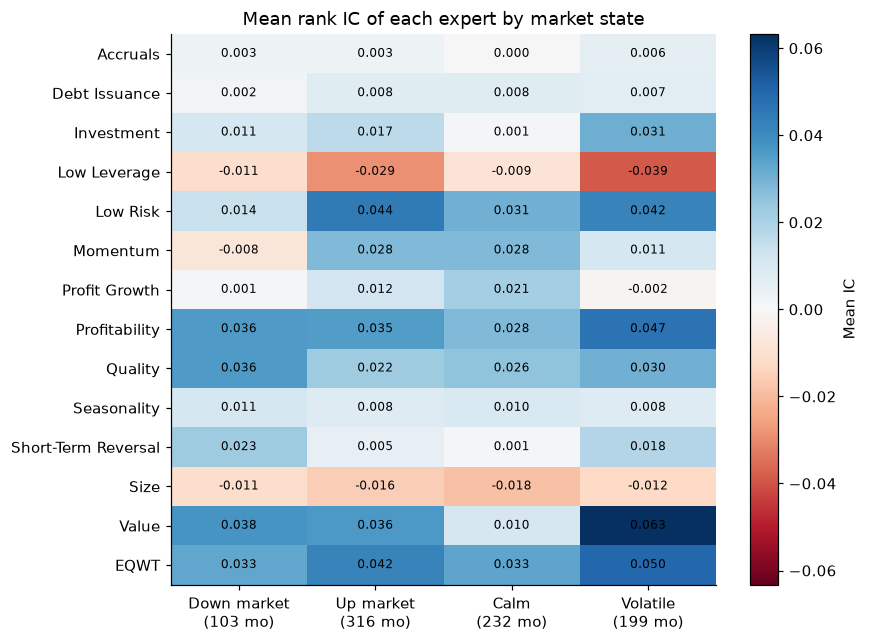

In [13]:
mkt = (wr.groupby(g).sum() / w.groupby(g).sum())              # VW universe return earned over t -> t+1
trail12 = mkt.shift(1).rolling(12).sum()                        # only returns realised by t
mstates = pd.DataFrame(index=ic.index)
mstates["Down market"] = trail12 < 0
mstates["Up market"] = trail12 >= 0
if "rvol_21d" in panel.columns:
    vol = panel.groupby(g)["rvol_21d"].median()
    hi_vol = vol > vol.expanding(12).median()
    mstates["Calm"] = ~hi_vol & vol.notna()
    mstates["Volatile"] = hi_vol
mstates = mstates.reindex(ic.index).fillna(False).astype(bool)

mkt_ic = pd.DataFrame({s: ic[mstates[s]].mean() for s in mstates})
n_months = mstates.sum()

fig, ax = plt.subplots(figsize=(8, 6.5))
vmax = np.nanmax(np.abs(mkt_ic.values))
im = ax.imshow(mkt_ic.values, aspect="auto", cmap="RdBu", vmin=-vmax, vmax=vmax)
ax.set_yticks(range(len(mkt_ic)), mkt_ic.index)
ax.set_xticks(range(mkt_ic.shape[1]), [f"{c}\n({n_months[c]} mo)" for c in mkt_ic.columns])
for i in range(mkt_ic.shape[0]):
    for j in range(mkt_ic.shape[1]):
        ax.text(j, i, f"{mkt_ic.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
ax.grid(False)
ax.set_title("Mean rank IC of each expert by market state")
fig.colorbar(im, ax=ax, label="Mean IC")
save(fig, "08_conditional_ic_market_states")

## 7. Save expert scores for the modeling step

In [14]:
out = pd.concat([panel[["id", "eom", "me", "size_grp", "ret_exc_lead1m"]],
                 expert[EXPERTS].astype("float32")], axis=1)
out.to_parquet(INTERIM / f"expert_scores_naive_{UNIVERSE}.parquet", index=False)
theme_ls.to_parquet(INTERIM / f"theme_factor_returns_{UNIVERSE}.parquet")
print(f"Saved {len(out):,} rows; figures in {FIG}")
sorted(p.name for p in FIG.glob("*.png"))

Saved 832,982 rows; figures in /Users/Roshan/Library/Mobile Documents/com~apple~CloudDocs/Documents/MIT MFin/Semesters/Fall 2/AIML Research in Finance/15.S06-MOE/outputs/figures


['01_universe.png',
 '02_missingness.png',
 '03_theme_cumulative.png',
 '04_theme_correlation.png',
 '05_rolling_sharpe.png',
 '06_expert_baselines.png',
 '07_conditional_ic_stock_states.png',
 '08_conditional_ic_market_states.png']

## Next steps

1. **Compare**: check `theme_factor_returns` against the US theme factors on jkpfactors.com (expect some differences, since JKP use all stocks).
2. **Fitted experts**: replace the naive average with one model per theme (ridge → LightGBM), trained on expanding windows,
   saving only out-of-sample predictions.
3. **Benchmarks**: pooled model on all 153 characteristics; EQWT of fitted experts.
4. **Gates**: softmax gate on stock states, on market states, and both; soft vs top-k routing.
5. **Evaluation**: IC, long-short Sharpe, turnover, and performance after costs, on the progress report's timeline: experts compared on 2006–2015, gate tested on 2016–2020,
   final holdout 2021–2025.